# MVP v0.2.5.3: Target Scorer Gradient Debugging

**Date:** 2026-03-13  
**Builds on:** MVP v0.2.5.2 (trajectory MSE analysis)

## Goal

Debug `RobomimicDiffusionScorer.grad_log_prob()` to determine whether the
target scorer gradients actually point toward the target policy's actions.

v0.2.5.2 showed that positive-only guidance *suppresses* success rate (60% → 24%),
suggesting the scorer gradients may be broken. This notebook runs 5 diagnostic
tests to identify the problem.

## Tests

1. Sigma & dimension check
2. Gradient direction test (does following the gradient move toward real actions?)
3. Gradient magnitude comparison (|grad| vs |action|)
4. Gradient field along a full trajectory
5. Perturbation gradient descent (iteratively recover real actions from random)

In [1]:
%matplotlib inline
import sys, os
import importlib
import numpy as np
import torch
import h5py
import json
import math
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils

import latent_sope.robomimic_interface.guidance as _guidance_mod
importlib.reload(_guidance_mod)
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_algo_from_checkpoint
)
from latent_sope.robomimic_interface.guidance import RobomimicDiffusionScorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
CKPT_DIR = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models/test/20260309132349"
TARGET_ROLLOUT_DIR = PROJECT_ROOT / "rollouts" / "target_policy_50"
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
STATE_DIM = 19
ACTION_DIM = 7

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
logit_scale                                                    | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


In [2]:
# ── Load target scorer ──
ckpt = load_checkpoint(CKPT_DIR, ckpt_path=Path("last.pth"))
target_algo = build_algo_from_checkpoint(ckpt, device=str(device))
scorer = RobomimicDiffusionScorer(target_algo, device=str(device), obs_keys=OBS_KEYS)

# ── Load target rollouts ──
target_data = []
rollout_paths = sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:50]
for path in rollout_paths:
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
        actions = f["actions"][:]
    states = latents[:, -1, :] if latents.ndim == 3 else latents
    target_data.append({
        "states": states.astype(np.float32),
        "actions": actions.astype(np.float32),
    })
print(f"Loaded {len(target_data)} target rollouts")


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_quat', 'robot0_eef_pos', 'robot0_gripper_qpos', 'object']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[15:58:47] INFO     build_algo_from_checkpoint took 0.54 seconds to execute                           ]8;id=632213;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=561836;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

Loaded 50 target rollouts


## Test 1: Sigma & Dimension Check

Check whether `sigma` at `score_timestep=1` is near zero (which would amplify
gradients massively), and verify the UNet dimension alignment with our chunk size.

In [3]:
print("=== Scorer Configuration ===")
print(f"score_timestep     = {scorer.score_timestep}")
print(f"sigma at t={scorer.score_timestep}       = {scorer.sigma:.6f}")
print(f"observation_horizon (To) = {scorer.observation_horizon}")
print(f"prediction_horizon  (Tp) = {scorer.prediction_horizon}")
print(f"action_start             = {scorer._action_start}")
print(f"action_dim               = {scorer.action_dim}")
print(f"state_dim                = {scorer.state_dim}")
print()

# How many chunk positions actually get scored vs padded?
CHUNK_SIZE = 4
scoreable = min(CHUNK_SIZE, scorer.prediction_horizon - scorer._action_start)
padded = CHUNK_SIZE - scoreable
print(f"With chunk_size={CHUNK_SIZE}:")
print(f"  Scoreable positions: {scoreable} (indices {scorer._action_start}..{scorer._action_start + scoreable - 1} of Tp={scorer.prediction_horizon})")
print(f"  Zero-padded positions: {padded}")
if padded > 0:
    print(f"  WARNING: {padded}/{CHUNK_SIZE} chunk positions have zero gradient!")
print()

# Show sigma across a range of timesteps for context
print("Sigma across timesteps:")
for t in [0, 1, 2, 5, 10, 50, 100]:
    if hasattr(scorer.noise_scheduler, "alphas_cumprod") and t < len(scorer.noise_scheduler.alphas_cumprod):
        ab = scorer.noise_scheduler.alphas_cumprod[t].item()
        sig = math.sqrt(1.0 - ab)
        print(f"  t={t:3d}: alpha_bar={ab:.6f}, sigma={sig:.6f}")

=== Scorer Configuration ===
score_timestep     = 1
sigma at t=1       = 0.041803
observation_horizon (To) = 2
prediction_horizon  (Tp) = 16
action_start             = 1
action_dim               = 7
state_dim                = 19

With chunk_size=4:
  Scoreable positions: 4 (indices 1..4 of Tp=16)
  Zero-padded positions: 0

Sigma across timesteps:
  t=  0: alpha_bar=0.999369, sigma=0.025125
  t=  1: alpha_bar=0.998253, sigma=0.041803
  t=  2: alpha_bar=0.996652, sigma=0.057858
  t=  5: alpha_bar=0.988967, sigma=0.105039
  t= 10: alpha_bar=0.966717, sigma=0.182437
  t= 50: alpha_bar=0.478265, sigma=0.722313


## Test 2: Gradient Direction Test

For each of 50 real (state, action) pairs, check whether following the scorer
gradient from a random action moves *closer* to the real action.

If the scorer works: `|a_rand + lr * grad(a_rand) - a_real| < |a_rand - a_real|`
most of the time. If it's ~50%, the gradient is random noise.

=== Gradient Direction Test (N=50, lr=0.1) ===
Fraction where gradient moved closer to real action: 10/50 (20.0%)
Mean relative distance improvement: -52.1%
  (>50% closer = gradient has signal, ~50% = random, <50% = wrong direction)

|grad| at real actions:   mean=15.0195, std=5.1366
|grad| at random actions: mean=58.0242, std=10.2221
  (expect: |grad_real| < |grad_rand| if real actions are near the mode)



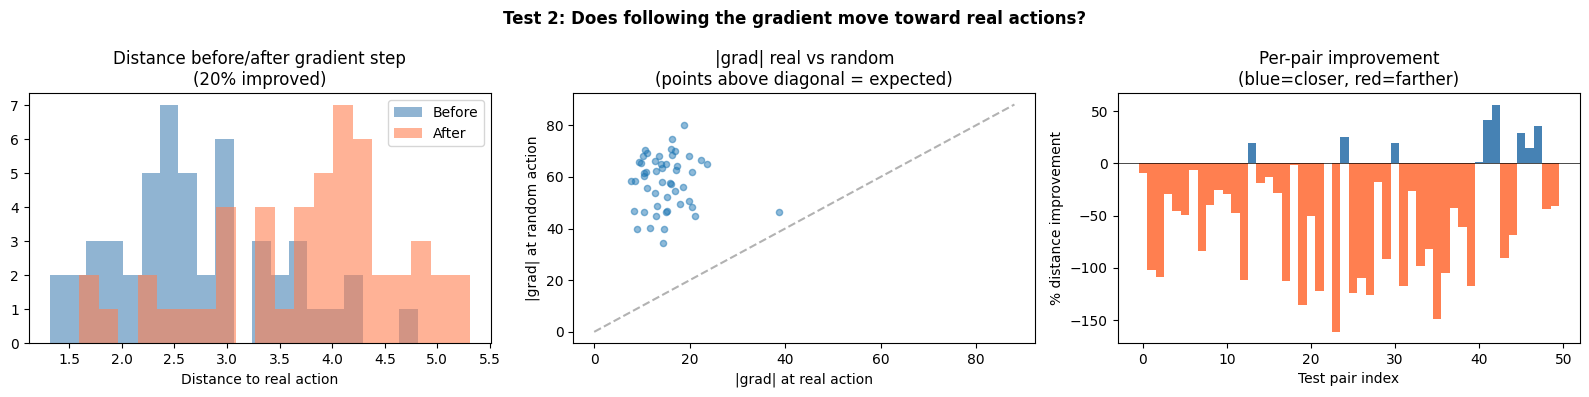

In [4]:
N_TEST = 50
LR_TEST = 0.1
np.random.seed(42)
torch.manual_seed(42)

closer_count = 0
grad_norms_real = []
grad_norms_rand = []
dist_before_list = []
dist_after_list = []

for i in range(N_TEST):
    ep_idx = i % len(target_data)
    ep = target_data[ep_idx]
    T = len(ep["states"]) - 1
    t_step = np.random.randint(0, T)
    
    s = torch.tensor(ep["states"][t_step:t_step+1], device=device)
    a_real = torch.tensor(ep["actions"][t_step:t_step+1], device=device)
    a_rand = torch.randn_like(a_real)
    
    grad_real = scorer.grad_log_prob(s, a_real)
    grad_rand = scorer.grad_log_prob(s, a_rand)
    
    grad_norms_real.append(grad_real.norm().item())
    grad_norms_rand.append(grad_rand.norm().item())
    
    a_updated = a_rand + LR_TEST * grad_rand
    dist_before = (a_rand - a_real).norm().item()
    dist_after = (a_updated - a_real).norm().item()
    dist_before_list.append(dist_before)
    dist_after_list.append(dist_after)
    
    if dist_after < dist_before:
        closer_count += 1

pct_closer = closer_count / N_TEST * 100
mean_improvement = np.mean([(b - a) / b for b, a in zip(dist_before_list, dist_after_list)])

print(f"=== Gradient Direction Test (N={N_TEST}, lr={LR_TEST}) ===")
print(f"Fraction where gradient moved closer to real action: {closer_count}/{N_TEST} ({pct_closer:.1f}%)")
print(f"Mean relative distance improvement: {mean_improvement*100:.1f}%")
print(f"  (>50% closer = gradient has signal, ~50% = random, <50% = wrong direction)")
print()
print(f"|grad| at real actions:   mean={np.mean(grad_norms_real):.4f}, std={np.std(grad_norms_real):.4f}")
print(f"|grad| at random actions: mean={np.mean(grad_norms_rand):.4f}, std={np.std(grad_norms_rand):.4f}")
print(f"  (expect: |grad_real| < |grad_rand| if real actions are near the mode)")
print()

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(dist_before_list, bins=20, alpha=0.6, color="steelblue", label="Before")
axes[0].hist(dist_after_list, bins=20, alpha=0.6, color="coral", label="After")
axes[0].set_xlabel("Distance to real action")
axes[0].set_title(f"Distance before/after gradient step\n({pct_closer:.0f}% improved)")
axes[0].legend()

axes[1].scatter(grad_norms_real, grad_norms_rand, alpha=0.5, s=20)
max_val = max(max(grad_norms_real), max(grad_norms_rand)) * 1.1
axes[1].plot([0, max_val], [0, max_val], "k--", alpha=0.3)
axes[1].set_xlabel("|grad| at real action")
axes[1].set_ylabel("|grad| at random action")
axes[1].set_title("|grad| real vs random\n(points above diagonal = expected)")

improvements = [(b - a) / b * 100 for b, a in zip(dist_before_list, dist_after_list)]
colors = ["coral" if imp < 0 else "steelblue" for imp in improvements]
axes[2].bar(range(N_TEST), improvements, color=colors, width=1.0)
axes[2].axhline(y=0, color="black", linewidth=0.5)
axes[2].set_xlabel("Test pair index")
axes[2].set_ylabel("% distance improvement")
axes[2].set_title("Per-pair improvement\n(blue=closer, red=farther)")

plt.suptitle("Test 2: Does following the gradient move toward real actions?", fontweight="bold")
plt.tight_layout()
plt.show()

## Test 3: Gradient Magnitude vs Action Magnitude

If `|grad| >> |action|`, then even a small `action_scale` (0.05) will dominate
the diffusion model output and destabilize trajectories.

=== Gradient vs Action Magnitudes (N=200) ===
|action|: mean=1.1181, std=0.1071
|grad|:   mean=14.4145, std=3.8769
|grad|/|action|: mean=12.86, median=12.59

  action_scale=0.05: guidance magnitude=0.7207 (64% of |action|)
  action_scale=0.1: guidance magnitude=1.4415 (129% of |action|)
  action_scale=0.2: guidance magnitude=2.8829 (258% of |action|)
  action_scale=0.5: guidance magnitude=7.2073 (645% of |action|)

Per-dimension |grad| vs |action| (mean):
  act_0: |action|=0.2158, |grad|=4.7879, ratio=22.18
  act_1: |action|=0.0786, |grad|=4.1516, ratio=52.81
  act_2: |action|=0.3589, |grad|=4.1092, ratio=11.45
  act_3: |action|=0.0147, |grad|=3.7801, ratio=257.38
  act_4: |action|=0.0378, |grad|=5.2803, ratio=139.64
  act_5: |action|=0.0496, |grad|=4.6087, ratio=92.90
  act_6: |action|=0.9918, |grad|=5.0299, ratio=5.07


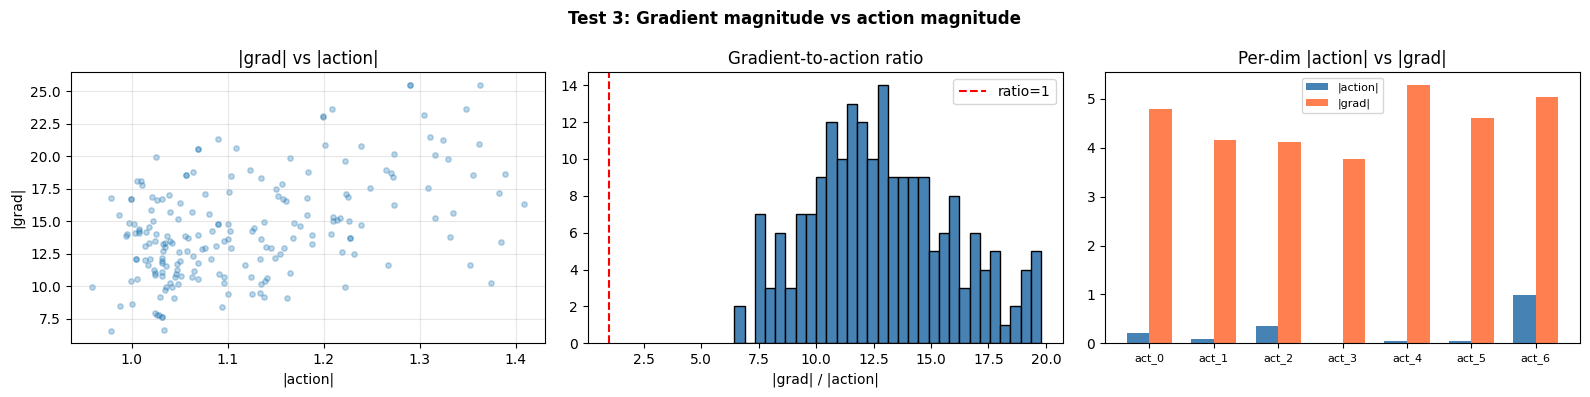

In [5]:
N_MAG = 200
action_norms = []
grad_norms = []
grad_per_dim = []  # (N, 7)
action_per_dim = []  # (N, 7)

for i in range(N_MAG):
    ep = target_data[i % len(target_data)]
    T = len(ep["states"]) - 1
    t_step = np.random.randint(0, T)
    
    s = torch.tensor(ep["states"][t_step:t_step+1], device=device)
    a = torch.tensor(ep["actions"][t_step:t_step+1], device=device)
    grad = scorer.grad_log_prob(s, a)
    
    action_norms.append(a.norm().item())
    grad_norms.append(grad.norm().item())
    grad_per_dim.append(grad[0].abs().cpu().numpy())
    action_per_dim.append(a[0].abs().cpu().numpy())

action_norms = np.array(action_norms)
grad_norms = np.array(grad_norms)
grad_per_dim = np.array(grad_per_dim)  # (N, 7)
action_per_dim = np.array(action_per_dim)  # (N, 7)
ratio_norms = grad_norms / (action_norms + 1e-8)

print(f"=== Gradient vs Action Magnitudes (N={N_MAG}) ===")
print(f"|action|: mean={action_norms.mean():.4f}, std={action_norms.std():.4f}")
print(f"|grad|:   mean={grad_norms.mean():.4f}, std={grad_norms.std():.4f}")
print(f"|grad|/|action|: mean={ratio_norms.mean():.2f}, median={np.median(ratio_norms):.2f}")
print()

# What guidance actually adds to the diffusion output
for scale in [0.05, 0.1, 0.2, 0.5]:
    guide_mag = scale * grad_norms.mean()
    pct_of_action = guide_mag / action_norms.mean() * 100
    print(f"  action_scale={scale}: guidance magnitude={guide_mag:.4f} ({pct_of_action:.0f}% of |action|)")
print()

# Per-dimension breakdown
print("Per-dimension |grad| vs |action| (mean):")
dim_names = ["act_0", "act_1", "act_2", "act_3", "act_4", "act_5", "act_6"]
for d in range(ACTION_DIM):
    print(f"  {dim_names[d]}: |action|={action_per_dim[:, d].mean():.4f}, "
          f"|grad|={grad_per_dim[:, d].mean():.4f}, "
          f"ratio={grad_per_dim[:, d].mean() / (action_per_dim[:, d].mean() + 1e-8):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(action_norms, grad_norms, alpha=0.3, s=15)
axes[0].set_xlabel("|action|")
axes[0].set_ylabel("|grad|")
axes[0].set_title("|grad| vs |action|")
axes[0].grid(True, alpha=0.3)

axes[1].hist(ratio_norms, bins=30, color="steelblue", edgecolor="black")
axes[1].axvline(x=1.0, color="red", linestyle="--", label="ratio=1")
axes[1].set_xlabel("|grad| / |action|")
axes[1].set_title("Gradient-to-action ratio")
axes[1].legend()

x_pos = np.arange(ACTION_DIM)
w = 0.35
axes[2].bar(x_pos - w/2, action_per_dim.mean(axis=0), w, label="|action|", color="steelblue")
axes[2].bar(x_pos + w/2, grad_per_dim.mean(axis=0), w, label="|grad|", color="coral")
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(dim_names, fontsize=8)
axes[2].set_title("Per-dim |action| vs |grad|")
axes[2].legend(fontsize=8)

plt.suptitle("Test 3: Gradient magnitude vs action magnitude", fontweight="bold")
plt.tight_layout()
plt.show()

## Test 4: Gradient Field Along a Full Trajectory

Score an entire real trajectory and visualize the gradient at each timestep.
If the scorer is consistent, gradients should be smooth. If spiky/noisy,
the score extraction is unreliable.

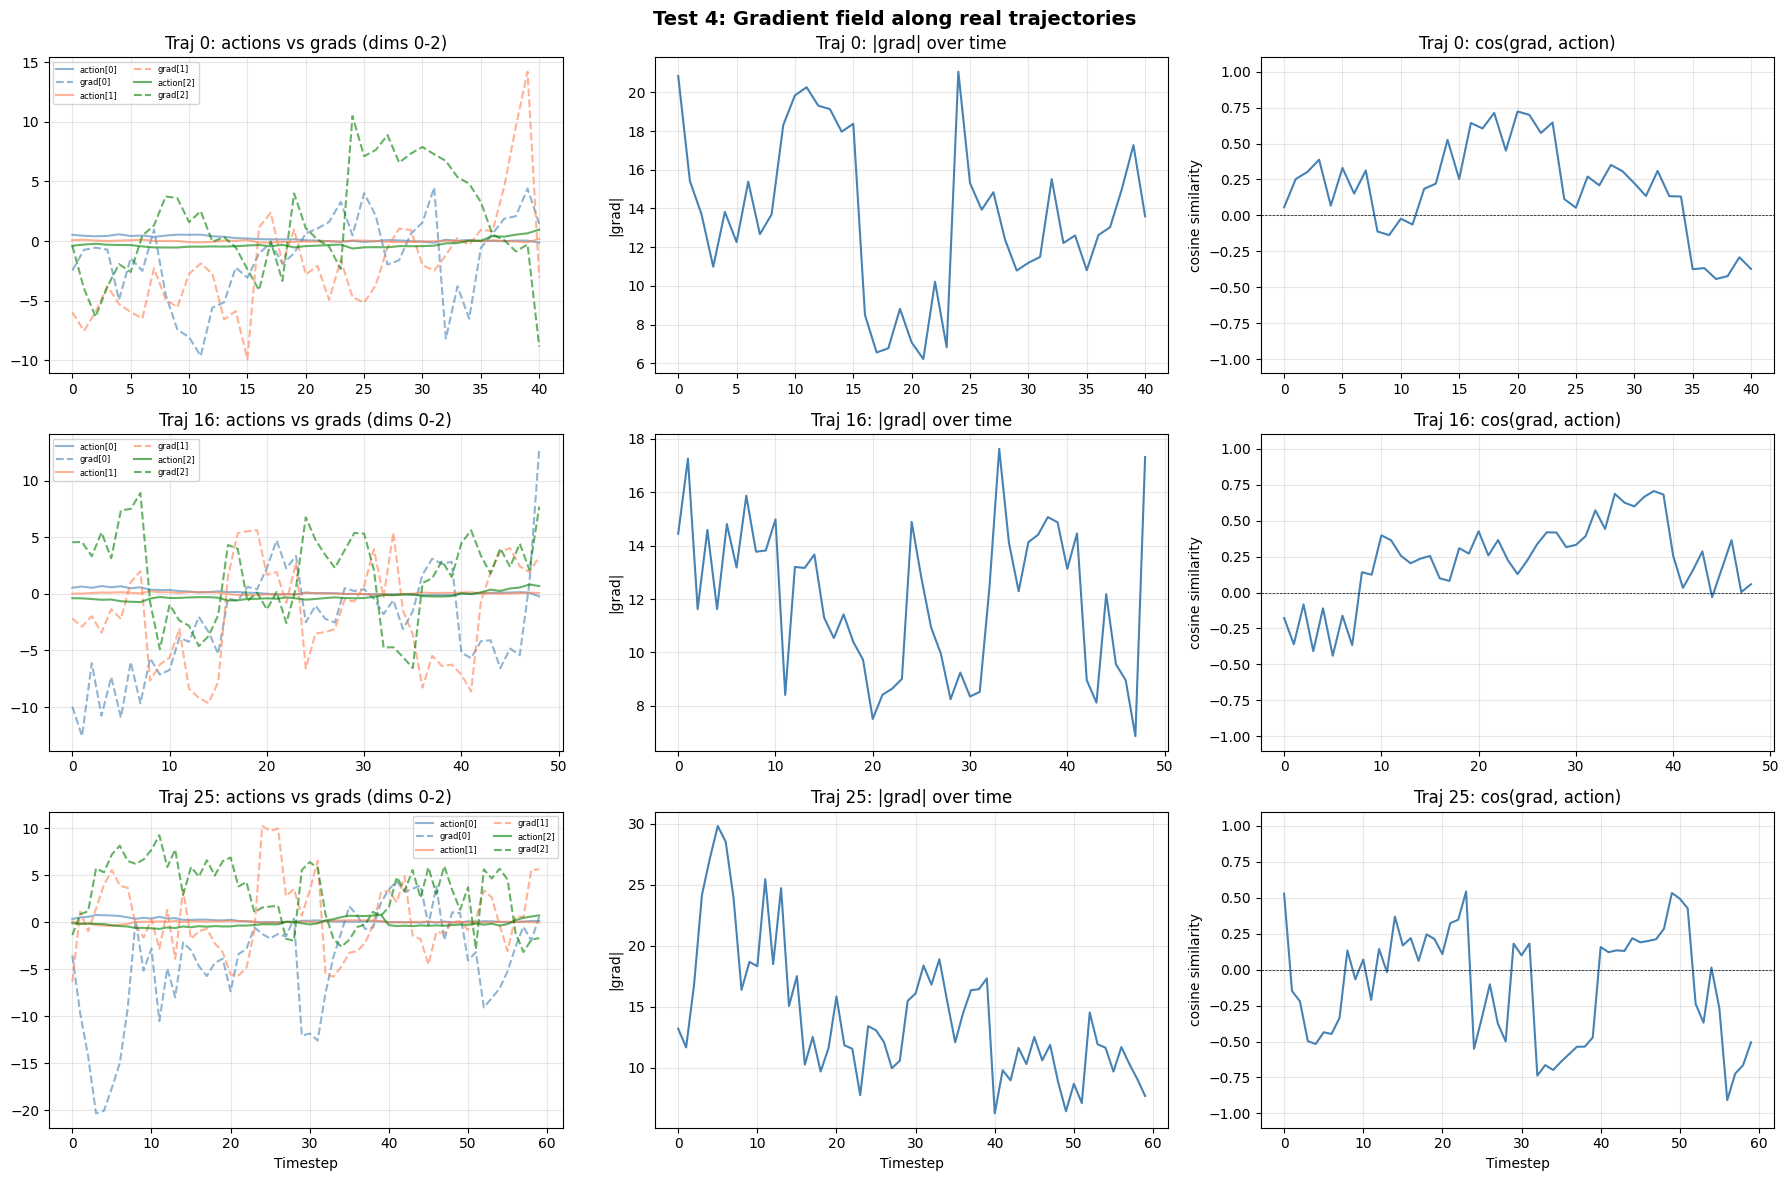

In [6]:
# Pick 3 trajectories of varying success
traj_indices = [0, len(target_data) // 3, len(target_data) // 2]

fig, axes = plt.subplots(len(traj_indices), 3, figsize=(18, 4 * len(traj_indices)))

for row, ep_idx in enumerate(traj_indices):
    ep = target_data[ep_idx]
    T = len(ep["actions"])
    
    # Score the full trajectory one timestep at a time
    # (grad_log_prob_chunk uses frame stacking from the chunk, so single-step
    # calls are cleaner for this diagnostic)
    all_grads = []
    for t in range(T):
        s = torch.tensor(ep["states"][t:t+1], device=device)
        a = torch.tensor(ep["actions"][t:t+1], device=device)
        g = scorer.grad_log_prob(s, a)
        all_grads.append(g[0].cpu().numpy())
    all_grads = np.array(all_grads)  # (T, 7)
    actions_np = ep["actions"][:T]
    
    # Panel 1: actions and gradients for dims 0, 1, 2
    ax = axes[row, 0]
    for d, color in zip([0, 1, 2], ["steelblue", "coral", "green"]):
        ax.plot(actions_np[:, d], color=color, alpha=0.6, label=f"action[{d}]")
        ax.plot(all_grads[:, d], color=color, alpha=0.6, linestyle="--", label=f"grad[{d}]")
    ax.set_title(f"Traj {ep_idx}: actions vs grads (dims 0-2)")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)
    
    # Panel 2: gradient norm over time
    ax = axes[row, 1]
    grad_norm_t = np.linalg.norm(all_grads, axis=-1)
    ax.plot(grad_norm_t, color="steelblue", linewidth=1.5)
    ax.set_title(f"Traj {ep_idx}: |grad| over time")
    ax.set_ylabel("|grad|")
    ax.grid(True, alpha=0.3)
    
    # Panel 3: cosine similarity between grad and action at each step
    ax = axes[row, 2]
    cos_sim = np.array([
        np.dot(all_grads[t], actions_np[t]) / (np.linalg.norm(all_grads[t]) * np.linalg.norm(actions_np[t]) + 1e-8)
        for t in range(T)
    ])
    ax.plot(cos_sim, color="steelblue", linewidth=1.5)
    ax.axhline(y=0, color="black", linewidth=0.5, linestyle="--")
    ax.set_ylim([-1.1, 1.1])
    ax.set_title(f"Traj {ep_idx}: cos(grad, action)")
    ax.set_ylabel("cosine similarity")
    ax.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Timestep")

plt.suptitle("Test 4: Gradient field along real trajectories", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Test 5: Perturbation Gradient Descent

Start from random actions, iteratively apply `a += lr * grad_log_prob(s, a)`.
If the scorer works, the actions should converge toward the policy's real actions.
This is the definitive test.

=== Perturbation Gradient Descent (N=20, steps=100, lr=0.01) ===
Converged toward real action: 18/20 (90%)
Initial distance:  mean=2.9770
Final distance:    mean=1.0044
Mean improvement:  66.3%

Final action std across pairs: 0.1937
Real action std across pairs:  0.1696
  (if final std << real std, gradient descent collapsed to a single point)


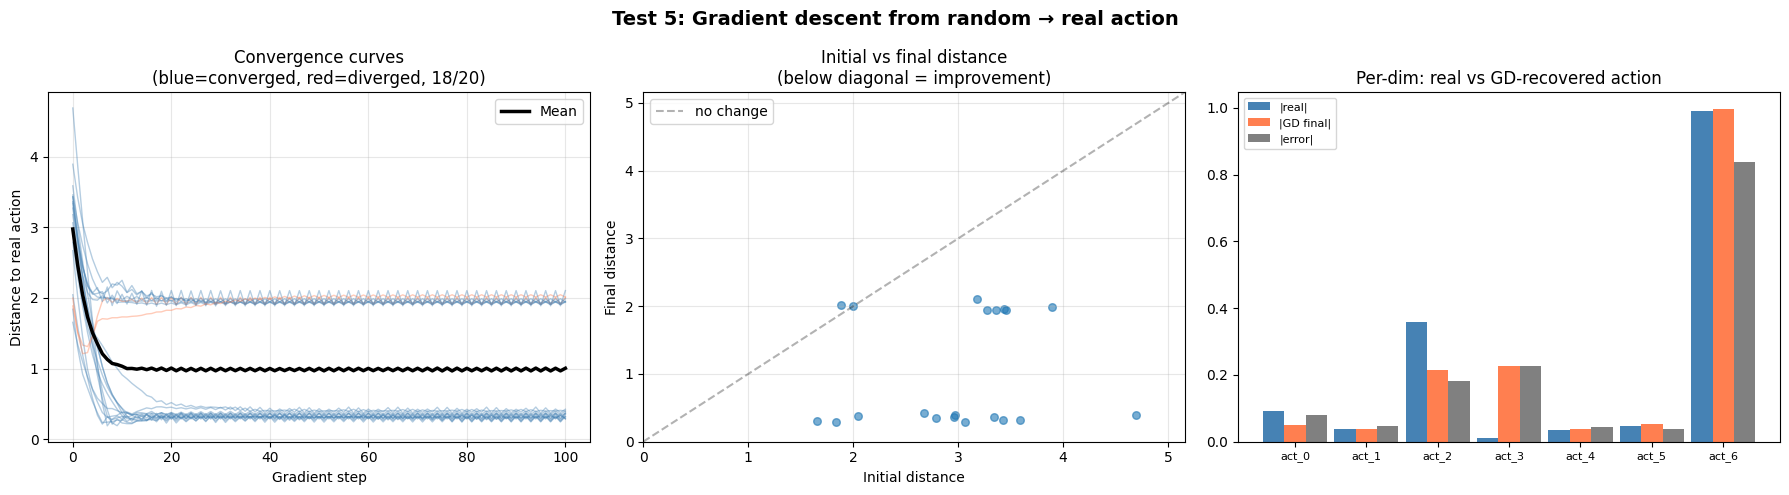

In [7]:
N_STEPS_GD = 100
LR_GD = 0.01
N_PAIRS_GD = 20
np.random.seed(123)
torch.manual_seed(123)

# Track convergence for each pair
convergence_curves = []  # (N_PAIRS, N_STEPS+1)
final_actions = []
real_actions_gd = []

for i in range(N_PAIRS_GD):
    ep = target_data[i % len(target_data)]
    T = len(ep["states"]) - 1
    t_step = T // 2  # mid-trajectory
    
    s = torch.tensor(ep["states"][t_step:t_step+1], device=device)
    a_real = torch.tensor(ep["actions"][t_step:t_step+1], device=device)
    a_curr = torch.randn_like(a_real)
    
    dists = []
    dists.append((a_curr - a_real).norm().item())
    
    for step in range(N_STEPS_GD):
        grad = scorer.grad_log_prob(s, a_curr)
        a_curr = a_curr + LR_GD * grad
        dists.append((a_curr - a_real).norm().item())
    
    convergence_curves.append(dists)
    final_actions.append(a_curr[0].cpu().numpy())
    real_actions_gd.append(a_real[0].cpu().numpy())

convergence_curves = np.array(convergence_curves)  # (N_PAIRS, N_STEPS+1)
final_actions = np.array(final_actions)
real_actions_gd = np.array(real_actions_gd)

# Summary
init_dists = convergence_curves[:, 0]
final_dists = convergence_curves[:, -1]
converged = np.sum(final_dists < init_dists)

print(f"=== Perturbation Gradient Descent (N={N_PAIRS_GD}, steps={N_STEPS_GD}, lr={LR_GD}) ===")
print(f"Converged toward real action: {converged}/{N_PAIRS_GD} ({converged/N_PAIRS_GD*100:.0f}%)")
print(f"Initial distance:  mean={init_dists.mean():.4f}")
print(f"Final distance:    mean={final_dists.mean():.4f}")
print(f"Mean improvement:  {(1 - final_dists.mean() / init_dists.mean()) * 100:.1f}%")
print()

# Did the gradient converge to SOMETHING (even if not the real action)?
# Check variance of final actions
print(f"Final action std across pairs: {final_actions.std(axis=0).mean():.4f}")
print(f"Real action std across pairs:  {real_actions_gd.std(axis=0).mean():.4f}")
print(f"  (if final std << real std, gradient descent collapsed to a single point)")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: convergence curves
for i in range(N_PAIRS_GD):
    color = "steelblue" if final_dists[i] < init_dists[i] else "coral"
    axes[0].plot(convergence_curves[i], color=color, alpha=0.4, linewidth=1)
axes[0].plot(convergence_curves.mean(axis=0), color="black", linewidth=2.5, label="Mean")
axes[0].set_xlabel("Gradient step")
axes[0].set_ylabel("Distance to real action")
axes[0].set_title(f"Convergence curves\n(blue=converged, red=diverged, {converged}/{N_PAIRS_GD})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: initial vs final distance scatter
axes[1].scatter(init_dists, final_dists, alpha=0.6, s=30)
max_d = max(init_dists.max(), final_dists.max()) * 1.1
axes[1].plot([0, max_d], [0, max_d], "k--", alpha=0.3, label="no change")
axes[1].set_xlabel("Initial distance")
axes[1].set_ylabel("Final distance")
axes[1].set_title("Initial vs final distance\n(below diagonal = improvement)")
axes[1].legend()
axes[1].set_xlim([0, max_d])
axes[1].set_ylim([0, max_d])
axes[1].grid(True, alpha=0.3)

# Panel 3: per-dimension comparison (final vs real)
x_pos = np.arange(ACTION_DIM)
w = 0.3
axes[2].bar(x_pos - w, np.abs(real_actions_gd).mean(axis=0), w, label="|real|", color="steelblue")
axes[2].bar(x_pos, np.abs(final_actions).mean(axis=0), w, label="|GD final|", color="coral")
axes[2].bar(x_pos + w, np.abs(final_actions - real_actions_gd).mean(axis=0), w, label="|error|", color="gray")
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([f"act_{d}" for d in range(ACTION_DIM)], fontsize=8)
axes[2].set_title("Per-dim: real vs GD-recovered action")
axes[2].legend(fontsize=8)

plt.suptitle("Test 5: Gradient descent from random → real action", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Test 5b: Gradient Descent with Multiple Learning Rates

If Test 5 fails, it might be a learning rate issue. Try a sweep.

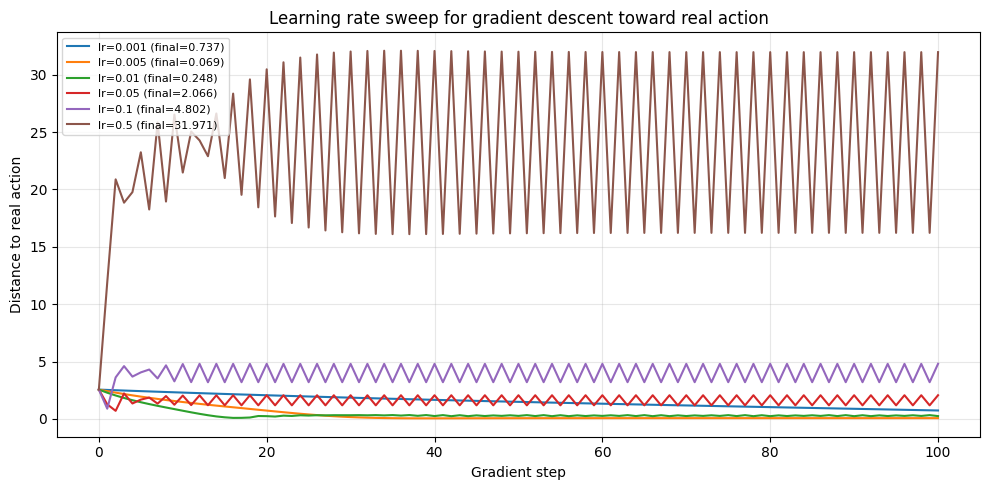

In [8]:
LR_SWEEP = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
N_STEPS_SWEEP = 100

# Use a single fixed (state, action) pair
ep = target_data[0]
t_step = len(ep["states"]) // 2
s = torch.tensor(ep["states"][t_step:t_step+1], device=device)
a_real = torch.tensor(ep["actions"][t_step:t_step+1], device=device)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for lr in LR_SWEEP:
    torch.manual_seed(0)
    a_curr = torch.randn_like(a_real)
    dists = [(a_curr - a_real).norm().item()]
    
    for step in range(N_STEPS_SWEEP):
        grad = scorer.grad_log_prob(s, a_curr)
        a_curr = a_curr + lr * grad
        dists.append((a_curr - a_real).norm().item())
    
    final_d = dists[-1]
    ax.plot(dists, label=f"lr={lr} (final={final_d:.3f})", linewidth=1.5)

ax.set_xlabel("Gradient step")
ax.set_ylabel("Distance to real action")
ax.set_title("Learning rate sweep for gradient descent toward real action")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

In [9]:
print("=" * 60)
print("MVP v0.2.5.3 SCORER DEBUG SUMMARY")
print("=" * 60)
print(f"\nScorer config:")
print(f"  score_timestep={scorer.score_timestep}, sigma={scorer.sigma:.6f}")
print(f"  To={scorer.observation_horizon}, Tp={scorer.prediction_horizon}, action_start={scorer._action_start}")
print()
print(f"Test 2 — Gradient direction:")
print(f"  {pct_closer:.0f}% moved closer (expect >50% if working)")
print()
print(f"Test 3 — Gradient magnitude:")
print(f"  |grad|/|action| ratio: mean={ratio_norms.mean():.2f}")
print(f"  Guidance at scale=0.1 is {0.1 * grad_norms.mean() / action_norms.mean() * 100:.0f}% of action magnitude")
print()
print(f"Test 5 — Gradient descent:")
print(f"  {converged}/{N_PAIRS_GD} converged toward real action")
print(f"  Mean improvement: {(1 - final_dists.mean() / init_dists.mean()) * 100:.1f}%")
print()
print("DIAGNOSIS:")
if pct_closer > 70 and converged > N_PAIRS_GD * 0.6:
    print("  Scorer gradients appear CORRECT.")
    print("  The guidance failure in v0.2.5.2 is likely a scale/integration issue.")
elif pct_closer > 50:
    print("  Scorer has WEAK signal — gradient direction is slightly better than random.")
    print("  May need different score_timestep, or the UNet score extraction is lossy.")
else:
    print("  Scorer gradients appear BROKEN — gradient direction is random or inverted.")
    print("  Investigate: sigma value, frame stacking, action sequence construction.")

MVP v0.2.5.3 SCORER DEBUG SUMMARY

Scorer config:
  score_timestep=1, sigma=0.041803
  To=2, Tp=16, action_start=1

Test 2 — Gradient direction:
  20% moved closer (expect >50% if working)

Test 3 — Gradient magnitude:
  |grad|/|action| ratio: mean=12.86
  Guidance at scale=0.1 is 129% of action magnitude

Test 5 — Gradient descent:
  18/20 converged toward real action
  Mean improvement: 66.3%

DIAGNOSIS:
  Scorer gradients appear BROKEN — gradient direction is random or inverted.
  Investigate: sigma value, frame stacking, action sequence construction.
